# Telling a post link from the other links

This notebook shows how well a rule built from URL templates and node content
separates the post links of a page from its navigation, tag and author links.

The data is `data/links.csv`, one row per link of the rendered semantic trees in
`server/feature/feed/testdata/semantic/`, labelled with the fixtures. Run
`python collect_links.py` again after the Go test rewrites the trees.

The rule under test has two steps:

1. **Normalize and group.** A link becomes a template such as
   `www.ycombinator.com/blog/{slug}`, and the links of a page are grouped by it.
2. **Select the groups.** A group is a post list when it holds two or more
   links, at least half of them carry a content signal (a heading, an image, or
   a text of 25 characters or more), and its number of signal carrying links is
   at least a tenth of the largest such number on the page.

In [2]:
import re
from urllib.parse import urlsplit

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

links = pd.read_csv("data/links.csv")
print(f"{len(links)} links, {links.page.nunique()} pages, {links.is_post.sum()} posts")
links.head()

2049 links, 21 pages, 1070 posts


,page,page_url,url,is_post,nodes,heading,images,texts,longest_text,datetime,min_depth,order,siblings,under_page_path,path_depth,title
0,anthropic.com-news,https://www.anthropic.com/news,https://support.claude.com/en/articles/9015913...,False,1,False,0,2,19,False,3,0,14,False,3,Non-media inquiries
1,anthropic.com-news,https://www.anthropic.com/news,https://anthropic.com/press-kit,False,1,False,0,2,18,False,3,1,14,False,1,Download press kit
2,anthropic.com-news,https://www.anthropic.com/news,https://www.anthropic.com/claude-fable-and-myt...,True,1,True,0,4,168,False,2,2,14,False,1,Our most advanced models for coding and knowle...
3,anthropic.com-news,https://www.anthropic.com/news,https://www.anthropic.com/institute/measuring-...,True,1,True,0,3,161,False,3,3,14,False,2,"Today, the world can’t see what’s going on ins..."
4,anthropic.com-news,https://www.anthropic.com/news,https://www.anthropic.com/threat-intelligence-...,True,1,True,0,4,315,False,3,4,14,False,1,"Over the past eight months, our Threat Intelli..."


## Normalizing a link

A path segment is replaced by a token when it names one post rather than a part
of the site. Three ways to decide that are implemented, so the effect of the
choice can be seen further down:

- `vocab`: keep the value only when the page uses it at the same position in two
  or more links.
- `look`: keep the value unless it is numeric, hash-like, contains `-` or `_`,
  or is long.
- `position`: replace every value at a position where the page uses many
  different values.

In [7]:
NUMBER = re.compile(r"^\d+$")
HASH = re.compile(r"^[0-9a-f]{7,}$", re.I)


def split_url(url):
    """host, path segments, and the trailing part that is kept as it is: the
    file extension and the sorted names of the query parameters."""
    parts = urlsplit(url)
    segments = [s for s in parts.path.split("/") if s]
    tail = ""
    if segments:
        m = re.search(r"\.([a-z0-9]{1,5})$", segments[-1], re.I)
        if m:
            tail = m.group(0).lower()
            segments[-1] = segments[-1][: m.start()]
    if parts.query:
        names = sorted({kv.split("=")[0] for kv in parts.query.split("&") if kv})
        tail += "?" + "&".join(names)
    return parts.netloc.lower(), segments, tail


def token(segment):
    if NUMBER.match(segment):
        return "{num}"
    if HASH.match(segment) and re.search(r"\d", segment):
        return "{hash}"
    return "{slug}"


def templates_of(urls, mode="vocab"):
    """Return {url: template} for the links of one page."""
    parsed = {u: split_url(u) for u in urls}
    times = {}
    for host, segments, _ in parsed.values():
        for i, s in enumerate(segments):
            times[(host, i, s.lower())] = times.get((host, i, s.lower()), 0) + 1
    varying = set()
    if mode == "position":
        values = {}
        for host, segments, _ in parsed.values():
            for i, s in enumerate(segments):
                values.setdefault((host, i), []).append(s.lower())
        for key, vs in values.items():
            distinct = len(set(vs))
            if distinct >= 3 and distinct / len(vs) > 0.5:
                varying.add(key)

    out = {}
    for url, (host, segments, tail) in parsed.items():
        tokens = []
        for i, s in enumerate(segments):
            generated = NUMBER.match(s) or (HASH.match(s) and re.search(r"\d", s))
            if mode == "vocab":
                literal = times[(host, i, s.lower())] >= 2 and not generated
            elif mode == "position":
                literal = (host, i) not in varying and not generated
            else:
                literal = "-" not in s and "_" not in s and len(s) < 16 and not generated
            tokens.append(s.lower() if literal else token(s))
        out[url] = host + "/" + "/".join(tokens) + tail
    return out


templates_of(links[links.page == "qiita.com"].url.tolist())

{'https://help.qiita.com/ja/articles/qiita-login-user': 'help.qiita.com/{slug}/{slug}/{slug}',
 'https://qiita.com/login?callback_action=login_or_signup&redirect_to=%2F&realm=qiita': 'qiita.com/{slug}?callback_action&realm&redirect_to',
 'https://qiita.com/signup?callback_action=login_or_signup&redirect_to=%2F&realm=qiita': 'qiita.com/{slug}?callback_action&realm&redirect_to',
 'https://qiita.com/tags/ai': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/%e7%94%9f%e6%88%90ai': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/llm': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/python': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/claudecode': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/aws': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/ai%e3%82%a8%e3%83%bc%e3%82%b8%e3%82%a7%e3%83%b3%e3%83%88': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/%e5%88%9d%e5%bf%83%e8%80%85': 'qiita.com/tags/{slug}',
 'https://qiita.com/tags/%e5%80%8b%e4%ba%ba%e9%96%8b%e7%99%ba': 'qiit

## The rule

`classify` adds three columns: the template of the link, whether its node
carries a content signal, and whether the rule selects it.

In [4]:
def classify(links, mode="vocab", min_members=2, min_signal=0.5, min_relative=0.1,
             min_text=25):
    pages = []
    for page, rows in links.groupby("page"):
        rows = rows.copy()
        rows["template"] = rows.url.map(templates_of(rows.url.tolist(), mode))
        rows["signal"] = (
            rows.heading | (rows.images > 0) | (rows.longest_text >= min_text)
        )
        groups = rows.groupby("template").agg(
            members=("url", "size"), signals=("signal", "sum"), posts=("is_post", "sum")
        )
        top = groups.signals.max()
        groups["selected"] = (
            (groups.members >= min_members)
            & (groups.signals / groups.members >= min_signal)
            & (groups.signals >= min_relative * top)
        )
        rows["predicted"] = rows.template.map(groups.selected)
        pages.append(rows)
    return pd.concat(pages, ignore_index=True)


def score(rows):
    tp = int((rows.predicted & rows.is_post).sum())
    fp = int((rows.predicted & ~rows.is_post).sum())
    fn = int((~rows.predicted & rows.is_post).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return pd.Series({"tp": tp, "fp": fp, "fn": fn, "precision": precision,
                      "recall": recall, "f1": f1})


result = classify(links)
score(result)

tp           1016.000000
fp             59.000000
fn             54.000000
precision       0.945116
recall          0.949533
f1              0.947319
dtype: float64

## Where the rule is right and where it is wrong

Each page contributes one bar. The length of the bar is the number of fixture
posts; the colours say what happened to the links of that page.

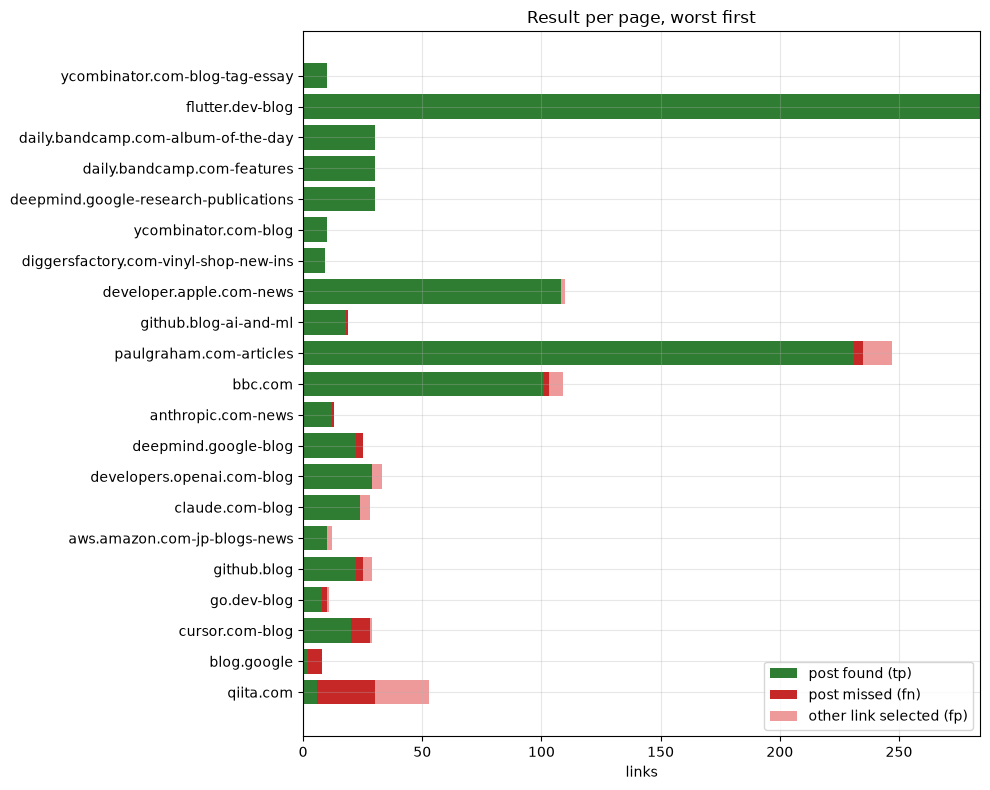

,tp,fp,fn,precision,recall
page,,,,,
qiita.com,6.0,23.0,24.0,0.21,0.20
blog.google,2.0,0.0,6.0,1.00,0.25
cursor.com-blog,20.0,1.0,8.0,0.95,0.71
go.dev-blog,8.0,1.0,2.0,0.89,0.80
github.blog,22.0,4.0,3.0,0.85,0.88
aws.amazon.com-jp-blogs-news,10.0,2.0,0.0,0.83,1.00
claude.com-blog,24.0,4.0,0.0,0.86,1.00
developers.openai.com-blog,29.0,4.0,0.0,0.88,1.00
deepmind.google-blog,22.0,0.0,3.0,1.00,0.88


In [6]:
per_page = result.groupby("page").apply(score, include_groups=False).sort_values("f1")

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(per_page))
ax.barh(y, per_page.tp, color="#2e7d32", label="post found (tp)")
ax.barh(y, per_page.fn, left=per_page.tp, color="#c62828", label="post missed (fn)")
ax.barh(y, per_page.fp, left=per_page.tp + per_page.fn, color="#ef9a9a",
        label="other link selected (fp)")
ax.set_yticks(list(y))
ax.set_yticklabels(per_page.index)
ax.set_xlabel("links")
ax.set_title("Result per page, worst first")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

per_page[["tp", "fp", "fn", "precision", "recall"]].round(2)

## The template groups of one page

Every dot is one template group. The rule keeps a group in the upper right area:
enough links, and enough of them carrying a content signal. A green dot is a
group that really holds posts, a red one does not.

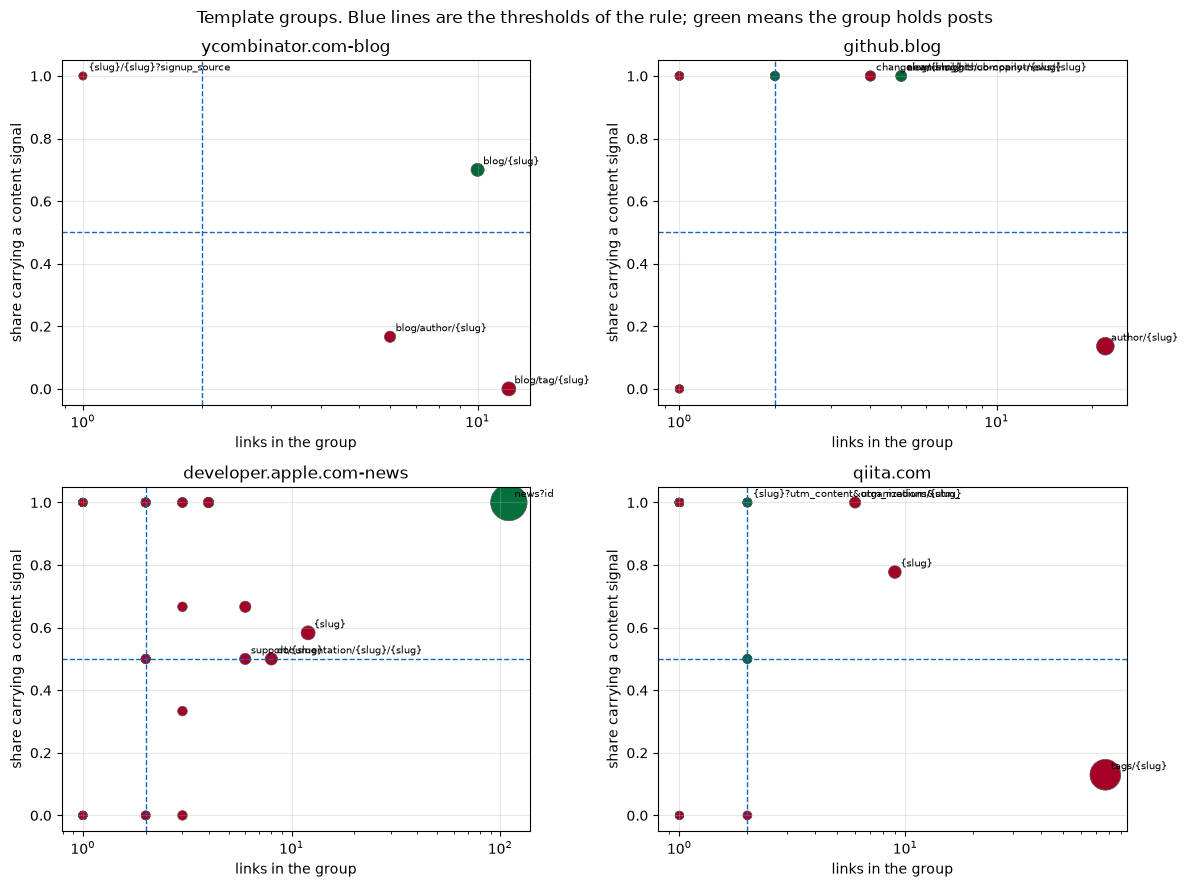

In [5]:
def plot_groups(rows, page, ax=None):
    rows = rows[rows.page == page]
    groups = rows.groupby("template").agg(
        members=("url", "size"), signals=("signal", "sum"), posts=("is_post", "sum")
    )
    groups["share"] = groups.signals / groups.members
    groups["truth"] = groups.posts / groups.members
    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(groups.members, groups.share, s=30 + groups.members * 6,
               c=groups.truth, cmap="RdYlGn", vmin=0, vmax=1,
               edgecolor="#555", linewidth=0.5)
    ax.axhline(0.5, color="#1565c0", linestyle="--", linewidth=1)
    ax.axvline(2, color="#1565c0", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("links in the group")
    ax.set_ylabel("share carrying a content signal")
    ax.set_title(page)
    for template, row in groups.sort_values("members", ascending=False).head(4).iterrows():
        ax.annotate(template.split("/", 1)[-1][:34], (row.members, row.share),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    return ax


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for page, ax in zip(["ycombinator.com-blog", "github.blog", "developer.apple.com-news",
                     "qiita.com"], axes.flat):
    plot_groups(result, page, ax)
fig.suptitle("Template groups. Blue lines are the thresholds of the rule; "
             "green means the group holds posts")
plt.tight_layout()
plt.show()

## What each part of the rule contributes

`content only` keeps every link whose node carries a content signal, with no
templates at all. `templates only` keeps every template group of two or more
links. `best template` is the single group with the best result on each page,
chosen with the fixtures in hand, so it is the ceiling of a rule that selects
exactly one group per page.

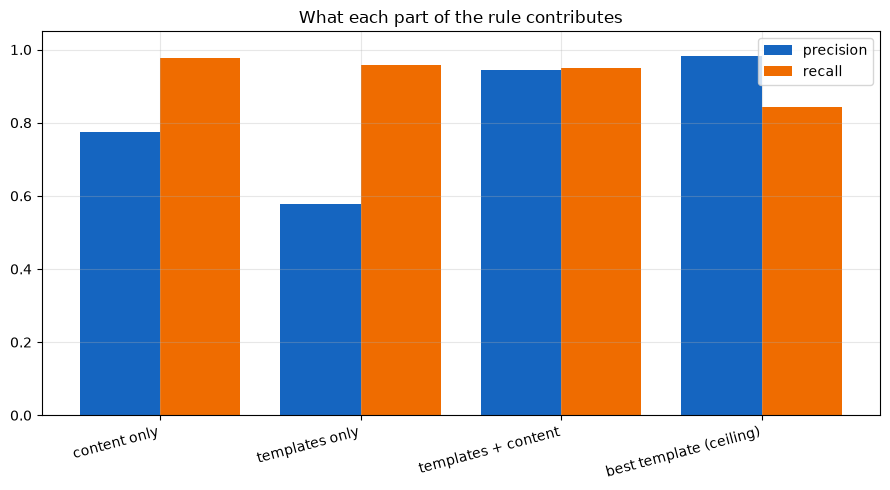

,tp,fp,fn,precision,recall,f1
content only,1046.0,303.0,24.0,0.78,0.98,0.86
templates only,1024.0,746.0,46.0,0.58,0.96,0.72
templates + content,1016.0,59.0,54.0,0.95,0.95,0.95
best template (ceiling),901.0,17.0,169.0,0.98,0.84,0.91


In [6]:
def content_only(links, min_text=25):
    rows = links.copy()
    rows["predicted"] = rows.heading | (rows.images > 0) | (rows.longest_text >= min_text)
    return rows


def templates_only(links, mode="vocab", min_members=2):
    pages = []
    for page, rows in links.groupby("page"):
        rows = rows.copy()
        rows["template"] = rows.url.map(templates_of(rows.url.tolist(), mode))
        size = rows.groupby("template").url.size()
        rows["predicted"] = rows.template.map(size >= min_members)
        pages.append(rows)
    return pd.concat(pages, ignore_index=True)


def best_template(links, mode="vocab"):
    pages = []
    for page, rows in links.groupby("page"):
        rows = rows.copy()
        rows["template"] = rows.url.map(templates_of(rows.url.tolist(), mode))
        posts = rows.is_post.sum()
        best, best_f1 = None, -1.0
        for template, group in rows.groupby("template"):
            hit = group.is_post.sum()
            if not hit:
                continue
            precision, recall = hit / len(group), hit / posts
            f1 = 2 * precision * recall / (precision + recall)
            if f1 > best_f1:
                best, best_f1 = template, f1
        rows["predicted"] = rows.template == best
        pages.append(rows)
    return pd.concat(pages, ignore_index=True)


comparison = pd.DataFrame({
    "content only": score(content_only(links)),
    "templates only": score(templates_only(links)),
    "templates + content": score(classify(links)),
    "best template (ceiling)": score(best_template(links)),
}).T

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(comparison))
ax.bar([i - 0.2 for i in x], comparison.precision, width=0.4, label="precision",
       color="#1565c0")
ax.bar([i + 0.2 for i in x], comparison.recall, width=0.4, label="recall",
       color="#ef6c00")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("What each part of the rule contributes")
plt.tight_layout()
plt.show()

comparison.round(2)

## The normalization rule matters

Keeping a segment by how it looks leaves too much literal text: on
`paulgraham.com` it produces almost one template per link. Deciding per position
is too aggressive and empties whole pages.

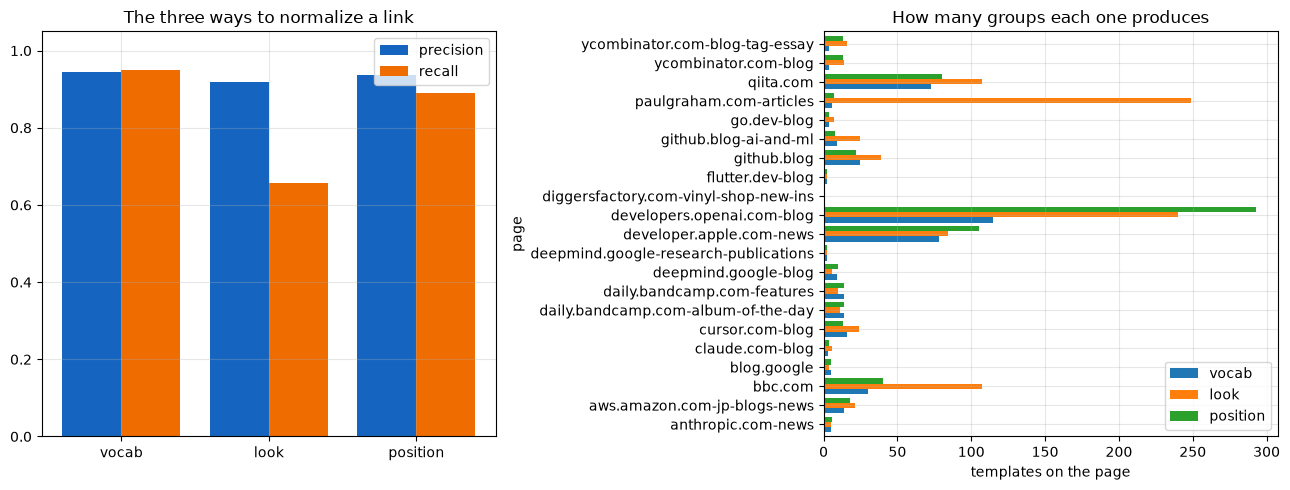

,tp,fp,fn,precision,recall,f1
vocab,1016.0,59.0,54.0,0.95,0.95,0.95
look,704.0,63.0,366.0,0.92,0.66,0.77
position,953.0,65.0,117.0,0.94,0.89,0.91


In [7]:
modes = pd.DataFrame({m: score(classify(links, mode=m))
                      for m in ["vocab", "look", "position"]}).T
counts = pd.DataFrame({
    m: classify(links, mode=m).groupby("page").template.nunique()
    for m in ["vocab", "look", "position"]
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = range(len(modes))
axes[0].bar([i - 0.2 for i in x], modes.precision, width=0.4, label="precision",
            color="#1565c0")
axes[0].bar([i + 0.2 for i in x], modes.recall, width=0.4, label="recall",
            color="#ef6c00")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(modes.index)
axes[0].set_ylim(0, 1.05); axes[0].legend()
axes[0].set_title("The three ways to normalize a link")

counts.plot.barh(ax=axes[1], width=0.8)
axes[1].set_xlabel("templates on the page")
axes[1].set_title("How many groups each one produces")
plt.tight_layout()
plt.show()

modes.round(2)

## The thresholds

The two numbers the rule is built on: how much of a group has to carry a content
signal, and how large a group has to be next to the largest group of the page.

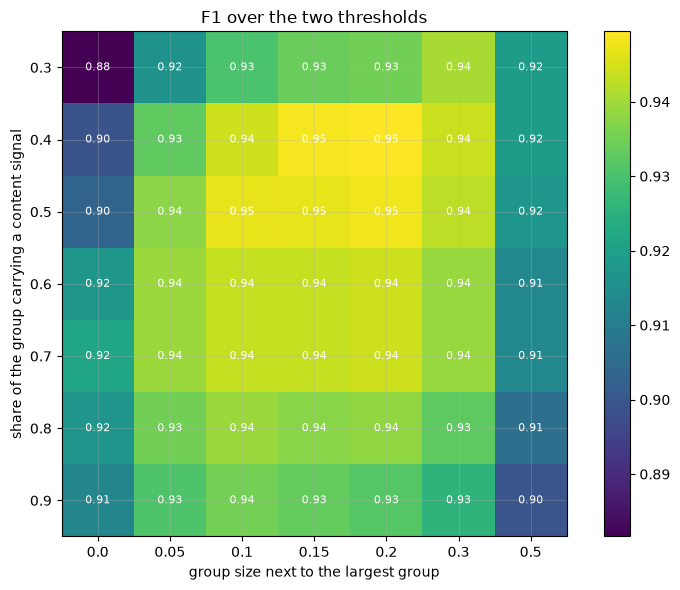

In [8]:
signal_steps = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
relative_steps = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
grid = pd.DataFrame(
    [[score(classify(links, min_signal=s, min_relative=r)).f1 for r in relative_steps]
     for s in signal_steps],
    index=signal_steps, columns=relative_steps)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid.values, cmap="viridis")
ax.set_xticks(range(len(relative_steps))); ax.set_xticklabels(relative_steps)
ax.set_yticks(range(len(signal_steps))); ax.set_yticklabels(signal_steps)
ax.set_xlabel("group size next to the largest group")
ax.set_ylabel("share of the group carrying a content signal")
ax.set_title("F1 over the two thresholds")
for i in range(len(signal_steps)):
    for j in range(len(relative_steps)):
        ax.text(j, i, f"{grid.values[i, j]:.2f}", ha="center", va="center",
                color="w", fontsize=8)
fig.colorbar(im)
plt.tight_layout()
plt.show()

## The links the rule gets wrong

The missed posts and the links it selects that are not posts, with the longest
text of the node so the shape of the mistake is readable.

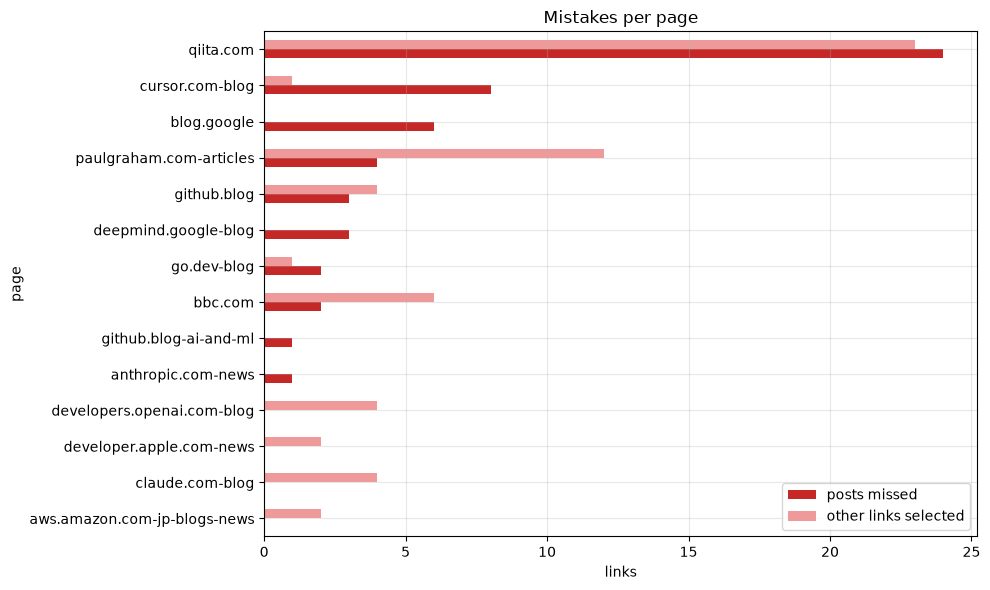

,page,url,template,longest_text,title
3,anthropic.com-news,https://www.anthropic.com/institute/measuring-...,www.anthropic.com/{slug}/{slug},161,"Today, the world can’t see what’s going on ins..."
96,bbc.com,https://www.bbc.com/sport/videos/ckqxvp07rrnvo,www.bbc.com/sport/videos/{slug},32,"Man United Fan - ""CARRICK GONE!"""
101,bbc.com,https://www.bbc.com/sport/cricket/videos/cmkg8...,www.bbc.com/sport/{slug}/{slug}/{slug},99,Stephen Fleming explains why he took the Engla...
187,blog.google,https://blog.google/innovation-and-ai/products...,blog.google/innovation-and-ai/{slug}/{slug}/{s...,131,"We’re launching the Gemini app for Windows, th..."
188,blog.google,https://blog.google/company-news/inside-google...,blog.google/{slug}/{slug}/{slug}/{slug},90,Our new Chicago office at Thompson Center brin...
190,blog.google,https://blog.google/innovation-and-ai/technolo...,blog.google/innovation-and-ai/technology/ai/{s...,126,Discover how filmmakers and Google DeepMind us...
192,blog.google,https://blog.google/innovation-and-ai/technolo...,blog.google/innovation-and-ai/technology/ai/{s...,0,NaN
193,blog.google,https://blog.google/innovation-and-ai/technolo...,blog.google/innovation-and-ai/technology/ai/{s...,0,NaN
194,blog.google,https://blog.google/innovation-and-ai/technolo...,blog.google/innovation-and-ai/technology/ai/{s...,0,NaN
229,cursor.com-blog,https://cursor.com/blog/projects,cursor.com/blog/projects,20,Introducing Projects


In [9]:
missed = result[~result.predicted & result.is_post]
wrong = result[result.predicted & ~result.is_post]

fig, ax = plt.subplots(figsize=(10, 6))
counts = pd.DataFrame({
    "posts missed": missed.groupby("page").size(),
    "other links selected": wrong.groupby("page").size(),
}).fillna(0).sort_values("posts missed")
counts = counts[counts.sum(axis=1) > 0]
counts.plot.barh(ax=ax, color=["#c62828", "#ef9a9a"])
ax.set_xlabel("links")
ax.set_title("Mistakes per page")
plt.tight_layout()
plt.show()

missed[["page", "url", "template", "longest_text", "title"]].head(20)

In [10]:
wrong[["page", "url", "template", "longest_text", "title"]].head(20)

,page,url,template,longest_text,title
21,aws.amazon.com-jp-blogs-news,https://aws.amazon.com/jp/blogs/news/category/...,aws.amazon.com/jp/blogs/news/category/artifici...,24,Amazon Bedrock AgentCore
42,aws.amazon.com-jp-blogs-news,https://aws.amazon.com/jp/blogs/news/category/...,aws.amazon.com/jp/blogs/news/category/artifici...,30,Amazon Bedrock Knowledge Bases
58,bbc.com,https://www.bbc.com/health,www.bbc.com/{slug},6,Health
59,bbc.com,https://www.bbc.com/weather,www.bbc.com/{slug},0,NaN
117,bbc.com,https://www.bbc.com/business,www.bbc.com/{slug},8,Business
122,bbc.com,https://www.bbc.com/technology,www.bbc.com/{slug},10,Technology
158,bbc.com,https://www.bbc.com/arts,www.bbc.com/{slug},4,Arts
163,bbc.com,https://www.bbc.com/future-planet,www.bbc.com/{slug},5,Earth
196,claude.com-blog,https://claude.com/blog-category/agents,claude.com/blog-category/{slug},6,Agents
197,claude.com-blog,https://claude.com/blog-category/claude-code,claude.com/blog-category/{slug},11,Claude Code


## Looking at one page

Change the name to read the templates of any page, largest group first.

In [11]:
def page_table(rows, page):
    rows = rows[rows.page == page]
    table = rows.groupby("template").agg(
        links=("url", "size"), signals=("signal", "sum"), posts=("is_post", "sum"),
        selected=("predicted", "first"))
    return table.sort_values("links", ascending=False)


page_table(result, "qiita.com").head(15)

,links,signals,posts,selected
template,,,,
qiita.com/tags/{slug},77,10,0,False
qiita.com/{slug},9,7,0,True
qiita.com/organizations/{slug},6,6,0,True
blog.qiita.com/{slug}?utm_content&utm_medium&utm_source,2,2,0,True
qiita.com/official-events/{hash},2,2,0,True
qiita.com/maskot1977/items/{hash},2,1,2,True
qiita.com/ktdatascience/items/{hash},2,1,2,True
qiita.com/suwa_nobu/items/{hash},2,2,2,True
increments.connpass.com/event/{num},2,2,0,True
